# **IgFold**: Fast, accurate antibody structure prediction

Official notebook for [IgFold](https://www.biorxiv.org/content/10.1101/2022.04.20.488972): Fast, accurate antibody structure prediction from deep learning on massive set of natural antibodies.  The code, data, and weights for this work are made available for non-commercial use. For commercial inquiries, please contact `jruffolo[at]jhu.edu`.

In [12]:
#@title Input antibody Fv sequences then press `Runtime` -> `Run all`

import os
import sys
print(sys.version)

python_version = f"{sys.version_info.major}.{sys.version_info.minor}"
print("Python version detected:", python_version)

name = "my_antibody" #@param {type:"string"}
pred_dir = name
os.makedirs(pred_dir, exist_ok=True)

#@markdown Enter antibody sequences for structure prediction. To predict a nanobody structure (or an individual heavy or light chain), simply provide one sequence.
heavy_sequence = "EVQLVQSGPEVKKPGTSVKVSCKASGFTFMSSAVQWVRQARGQRLEWIGWIVIGSGNTNYAQKFQERVTITRDMSTSTAYMELSSLRSEDTAVYYCAAPYCSSISCNDGFDIWGQGTMVTVS" #@param {type:"string"}
light_sequence = "DVVMTQTPFSLPVSLGDQASISCRSSQSLVHSNGNTYLHWYLQKPGQSPKLLIYKVSNRFSGVPDRFSGSGSGTDFTLKISRVEAEDLGVYFCSQSTHVPYTFGGGTKLEIK" #@param {type:"string"}

sequences = {}
if len(heavy_sequence) > 0:
    sequences["H"] = heavy_sequence
if len(light_sequence) > 0:
    sequences["L"] = light_sequence

#@markdown Perform structural refinement with OpenMM
do_refine = False #@param {type:"boolean"}
#@markdown Renumber predicted antibody structure (Chothia) with AbNumber
do_renum = False #@param {type:"boolean"}
#@markdown Use only a single model for predictions (instead of model ensemble)
single_model = False #@param {type:"boolean"}

3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Python version detected: 3.12


In [2]:
#nur pip und setuptools installen, dann runtime manuell neu starten!
!pip install --upgrade pip setuptools wheel
print("Bitte jetzt die Runtime neu starten: Runtime -> Restart runtime")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 48.6 MB/s eta 0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 75.2.0
    Uninstalling setuptools-75.2.0:
      Successfully uninstalled setuptools-75.2.0
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.


Bitte jetzt die Runtime neu starten: Runtime -> Restart runtime


In [3]:
#jetzt restliche pakete installieren, NACH manuellem Neustart
# Zelle 2: Installation der restlichen Pakete
!pip uninstall -y igfold torch torchvision torchaudio pytorch-lightning scipy numpy openmm abnumber -q

# Installiere numpy 2.x und scipy (aktuelle Version)
!pip install numpy==2.2.4 scipy

!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install openmm pdbfixer
!pip install igfold
!pip install abnumber
!pip install py3Dmol matplotlib seaborn
print("✅ Installation komplett")

  Using cached numpy-2.2.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
  Using cached scipy-1.17.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
Using cached numpy-2.2.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.1 MB)
Using cached scipy-1.17.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (35.0 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [scipy]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
anarcii 2.0.5 requires torch, which is not installed.
torchmetrics 1.8.2 requires torch>=2.0.0, which is not installed.
fastai 2.8.6 requires torch<2.10,>=1.10, which is not installed.
fastai 2.8.6 requires torchvision>=0.11, which is not installed.
accelerate 1.12.0 requires torch>=2.0.0, which is not installed.
sentence-transformers 5.2.0 requires torch>=1.11.0, whic

Looking in indexes: https://download.pytorch.org/whl/cu118
  Using cached https://download.pytorch.org/whl/cu118/torch-2.7.1%2Bcu118-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (28 kB)
  Using cached https://download.pytorch.org/whl/cu118/torchvision-0.22.1%2Bcu118-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (6.1 kB)
  Using cached https://download.pytorch.org/whl/cu118/torchaudio-2.7.1%2Bcu118-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (6.6 kB)
Using cached https://download.pytorch.org/whl/cu118/torch-2.7.1%2Bcu118-cp312-cp312-manylinux_2_28_x86_64.whl (905.2 MB)
Using cached https://download.pytorch.org/whl/cu118/torchvision-0.22.1%2Bcu118-cp312-cp312-manylinux_2_28_x86_64.whl (6.7 MB)
Using cached https://download.pytorch.org/whl/cu118/torchaudio-2.7.1%2Bcu118-cp312-cp312-manylinux_2_28_x86_64.whl (3.3 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [torchaudio]
  Using cached openmm-8.4.0.post2-cp312-cp312-manylinux_2_34_x86_64.whl.metadata (1.2 kB)
ERROR: Could not f

In [ ]:
#@title Install dependencies pip only, default IgFold changed

#@title Install dependencies (Colab-stable, pip-only)

import sys
import os

print("Python version:", sys.version)

# 1) Clean up potentially broken installs
!pip uninstall -y igfold torch torchvision torchaudio pytorch-lightning scipy numpy openmm abnumber -q

# 2) Update build tools
!pip install -U pip setuptools wheel

# 3) Install PyTorch (Colab-compatible CUDA)
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

# 4) Install scientific stack (fixed versions = no ABI issues)
!pip install numpy==1.26.4 scipy==1.10.1 pandas

# 5) Install OpenMM (for refinement)
!pip install openmm pdbfixer

# 6) Install IgFold
!pip install igfold

# 7) Install AbNumber (for renumbering)
!pip install abnumber

# 8) Optional visualization deps
!pip install py3Dmol matplotlib seaborn

print("✅ Installation complete. PLEASE restart the runtime now.")


Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 81.4 MB/s eta 0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 75.2.0
    Uninstalling setuptools-75.2.0:
      Successfully uninstalled setuptools-75.2.0
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
fastai 2.8.6 requires scipy, which is not installed.
fastai 2.8.6 requires torch<2.10,>=1.10, which is not installed.
fastai 2.8.6 requires torchvision>=0.11, which is not installed.
cufflinks 0.17.3 requires numpy>=1.9.2, which is not installed.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.

Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 150.9 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 58.8 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 173.8 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 32.9 MB/s  0:00:15
     ━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━ 156.2/417.9 MB 257.7 MB/s eta 0:00:02^C


In [13]:
#@title Predict antibody structure with IgFold
# added: Dynamisch Python-Version holen (Major.Minor), z.B. "3.12"
import sys
python_version = f"{sys.version_info.major}.{sys.version_info.minor}"

if f"/usr/local/lib/python{python_version}/site-packages/" not in sys.path:
    sys.path.insert(0, f"/usr/local/lib/python{python_version}/site-packages/")

from transformers.models.bert.tokenization_bert import BertTokenizer, BasicTokenizer, WordpieceTokenizer
from transformers.tokenization_utils import Trie
from torch.serialization import add_safe_globals

add_safe_globals([BertTokenizer, Trie, BasicTokenizer, WordpieceTokenizer])

!git clone https://github.com/openmm/pdbfixer.git
%cd pdbfixer
!pip install .
%cd ..

from igfold.utils.visualize import *
from igfold import IgFoldRunner

num_models = 1 if single_model else 4
igfold = IgFoldRunner(num_models=num_models)

pred_pdb = os.path.join(pred_dir, f"{name}.pdb")
pred = igfold.fold(
    pred_pdb,
    sequences=sequences,
    do_refine=do_refine,
    use_openmm=True,
    do_renum=do_renum,
)
show_pdb(pred_pdb, len(sequences), bb_sticks=False, sc_sticks=True, color="rainbow")

fatal: destination path 'pdbfixer' already exists and is not an empty directory.
/content/pdbfixer
Processing /content/pdbfixer
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for pdbfixer: filename=pdbfixer-1.12.0-py3-none-any.whl size=681765 sha256=3c94cf5e149cc998f1effe255e704c0500d6d2d5011baa935a6b622aaadcc7d0
  Stored in directory: /tmp/pip-ephem-wheel-cache-su_dot4b/wheels/88/64/25/79f63584c13565c0a3de64cee3759b9080b9ed3d6c31a4ab23
Successfully built pdbfixer
  Attempting uninstall: pdbfixer
    Found existing installation: pdbfixer 1.12.0
    Uninstalling pdbfixer-1.12.0:
      Successfully uninstalled pdbfixer-1.12.0


/content

    The code, data, and weights for this work are made available for non-commercial use 
    (including at commercial entities) under the terms of the JHU Academic Software License 
    Agreement. For commercial inquiries, please contact awichma2[at]jhu.edu.
    License: https://github.com/Graylab/IgFold/blob/main/LICENSE.md
    
Loading 4 IgFold models...
Using device: cpu
Loading /usr/local/lib/python3.12/dist-packages/igfold/trained_models/IgFold/igfold_1.ckpt...
Loading /usr/local/lib/python3.12/dist-packages/igfold/trained_models/IgFold/igfold_2.ckpt...
Loading /usr/local/lib/python3.12/dist-packages/igfold/trained_models/IgFold/igfold_3.ckpt...
Loading /usr/local/lib/python3.12/dist-packages/igfold/trained_models/IgFold/igfold_5.ckpt...
Successfully loaded 4 IgFold models.
Loaded AntiBERTy model.
Completed folding in 51.79 seconds.


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

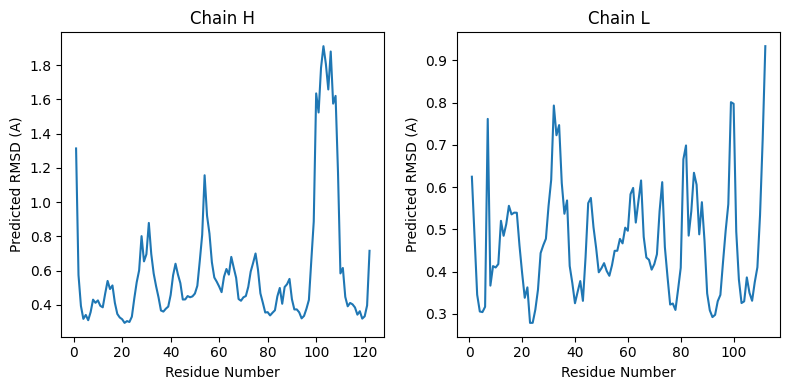

In [14]:
#@title Plot per-residue predicted RMSD

prmsd_fig_file = os.path.join(pred_dir, f"{name}_prmsd.png")
plot_prmsd(sequences, pred.prmsd.cpu(), prmsd_fig_file, shade_cdr=do_renum, pdb_file=pred_pdb)

In [15]:
#@title Show predicted structure with predicted RMSD

#@markdown Structure is colored from low (blue) to high (red) pRMSD.

show_pdb(pred_pdb, len(sequences), bb_sticks=False, sc_sticks=True, color="b")

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [ ]:
#@title Download results

#@markdown Download zip file containing structure prediction and annotation results. If download fails, results are also accessible from file explorer on the left panel of the notebook.

from google.colab import files
import locale
locale.getpreferredencoding = lambda: "UTF-8"

!zip -FSr $name".result.zip" $pred_dir/ &> /dev/null
files.download(f"{name}.result.zip")